a. Design a single unit perceptron for classification of a linearly separable binary dataset (placement.csv)
without using pre-defined models. Use the Perceptron() from sklearn.

[[ 1. -1.]]
[1.]
accuracy score is 0.2541


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

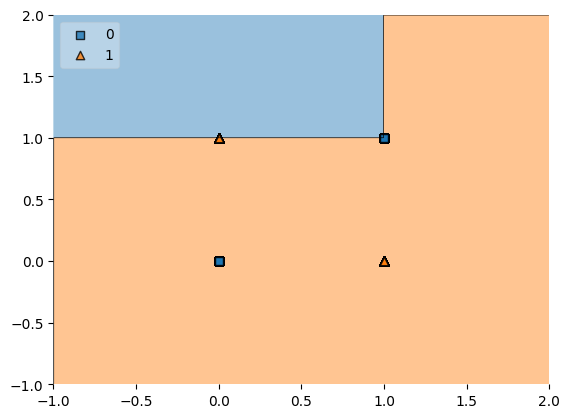

In [ ]:
# Single unit perceptron
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
df=pd.read_csv('Xor_Dataset.csv')
X = df.iloc[:,0:2]
y = df.iloc[:,-1]
p = Perceptron()
p.fit(X,y)
print(p.coef_)
print(p.intercept_)
z=p.score(X,y)
print("accuracy score is",z)
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values, y.values, clf=p, legend=2)

Weights: [[2. 2.]]
Bias: [-1.]
Accuracy score is: 1.0


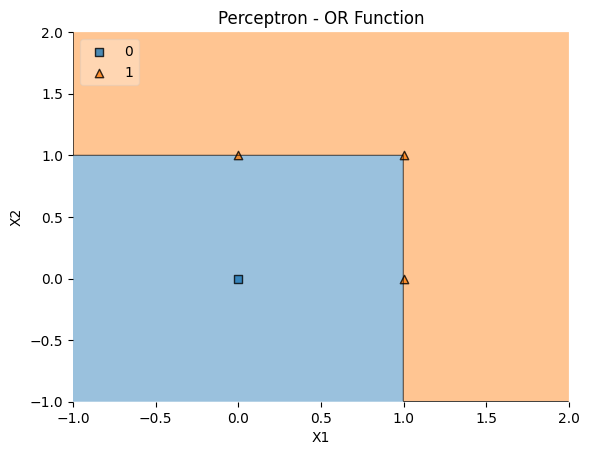

In [ ]:
# Single unit perceptron (HARDCODED DATA)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from mlxtend.plotting import plot_decision_regions

# -------------------------------
# HARDCODED OR DATASET
# -------------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,1,1,1])

# -------------------------------
# TRAIN PERCEPTRON
# -------------------------------
p = Perceptron()

p.fit(X, y)

# -------------------------------
# OUTPUT
# -------------------------------
print("Weights:", p.coef_)
print("Bias:", p.intercept_)

z = p.score(X, y)
print("Accuracy score is:", z)

# -------------------------------
# PLOT DECISION REGION
# -------------------------------
plot_decision_regions(X, y, clf=p, legend=2)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Perceptron - OR Function")

plt.show()


Weights: [[2. 2.]]
Bias: [-2.]
Accuracy score is: 1.0


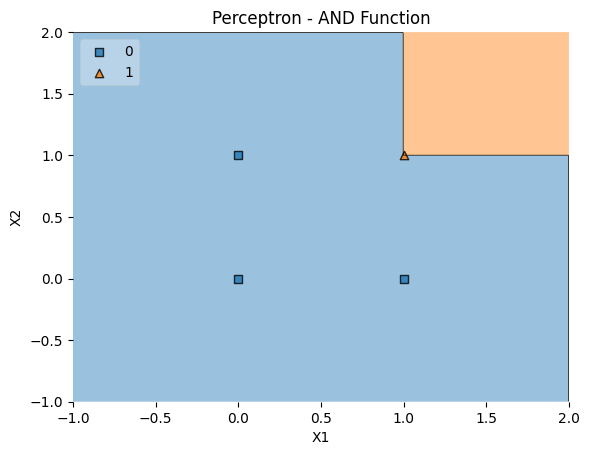

In [ ]:
# Single unit perceptron (HARDCODED DATA - AND)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from mlxtend.plotting import plot_decision_regions

# -------------------------------
# HARDCODED DATA (AND)
# -------------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([0,0,0,1])   # <-- changed here

# -------------------------------
# TRAIN PERCEPTRON
# -------------------------------
p = Perceptron()

p.fit(X, y)

# -------------------------------
# OUTPUT
# -------------------------------
print("Weights:", p.coef_)
print("Bias:", p.intercept_)

z = p.score(X, y)
print("Accuracy score is:", z)

# -------------------------------
# PLOT DECISION REGION
# -------------------------------
plot_decision_regions(X, y, clf=p, legend=2)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Perceptron - AND Function")

plt.show()

Exercise:
Design a single unit perceptron for classification of a linearly separable binary dataset without using pre-defined
models. Use the Perceptron() from sklearn.

In [ ]:
#hint-use make_classification() to generate binary dataset from sklearn
#Eg:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, n_features=2,
n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1,
random_state=41,hypercube=False,class_sep=10)

Identify the problem with single unit Perceptron. Classify using Or-, And- and Xor-ed data and analyse the result.

[[2. 2.]]
[-2.]
[[2. 2.]]
[-1.]
[[0. 0.]]
[0.]


<Axes: >

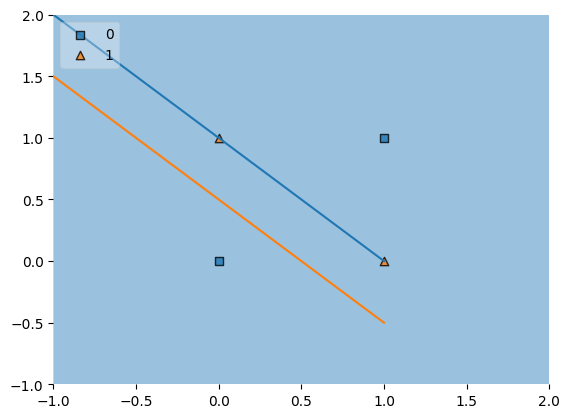

In [ ]:
# Perceptron on Or-, And- and Xor-ed data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
or_data = pd.DataFrame()
and_data = pd.DataFrame()
xor_data = pd.DataFrame()
or_data['input1']=[1,1,0,0]
or_data['input2']=[1,0,1,0]
or_data['ouput']=[1,1,1,0]
and_data['input1']=[1,1,0,0]
and_data['input2']=[1,0,1,0]
and_data['ouput']=[1,0,0,0]
xor_data['input1']=[1,1,0,0]
xor_data['input2']=[1,0,1,0]
xor_data['ouput']=[0,1,1,0]
from sklearn.linear_model import Perceptron
clf1=Perceptron()
clf2=Perceptron()
clf3=Perceptron()
clf1.fit(and_data.iloc[:,0:2].values,and_data.iloc[:,-1].values)
print(clf1.coef_)
print(clf1.intercept_)
x=np.linspace(-1,1,5)
y=-x+1
plt.plot(x,y)
#sns.scatterplot(and_data['input1'],and_data['input2'],hue=and_data['ouput'],s=200)
clf2.fit(or_data.iloc[:,0:2].values,or_data.iloc[:,-1].values)
print(clf2.coef_)
print(clf2.intercept_)
x1=np.linspace(-1,1,5)
y1=-x+0.5
plt.plot(x1,y1)
#sns.scatterplot(or_data['input1'],or_data['input2'],hue=or_data['ouput'],s=200)
clf3.fit(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values)
print(clf3.coef_)
print(clf3.intercept_)
plot_decision_regions(xor_data.iloc[:,0:2].values,xor_data.iloc[:,-1].values,
clf=clf3, legend=2)

Predicted:
[[0.]
 [1.]
 [1.]
 [0.]]


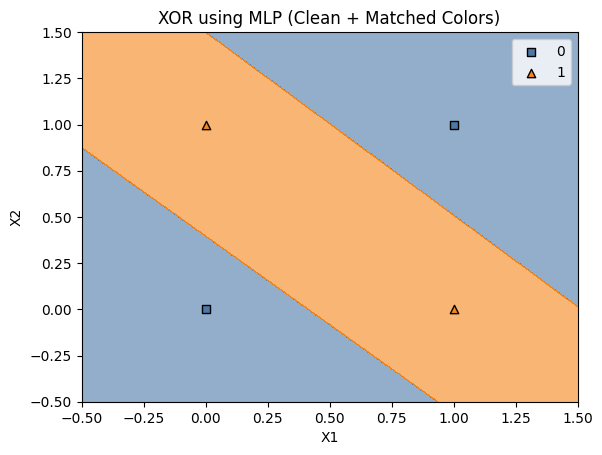

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# -------------------------------
# XOR DATASET
# -------------------------------
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0], [1], [1], [0]])

# -------------------------------
# ACTIVATION FUNCTIONS
# -------------------------------
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    return x * (1 - x)

# -------------------------------
# INITIALIZE WEIGHTS
# -------------------------------
np.random.seed(1)

W1 = np.random.randn(2, 2)
b1 = np.zeros((1, 2))

W2 = np.random.randn(2, 1)
b2 = np.zeros((1, 1))

# -------------------------------
# TRAINING
# -------------------------------
for epoch in range(10000):

    hidden = sigmoid(np.dot(X, W1) + b1)
    output = sigmoid(np.dot(hidden, W2) + b2)

    error = y - output

    d_output = error * sigmoid_deriv(output)
    d_hidden = np.dot(d_output, W2.T) * sigmoid_deriv(hidden)

    W2 += np.dot(hidden.T, d_output)
    b2 += np.sum(d_output, axis=0, keepdims=True)

    W1 += np.dot(X.T, d_hidden)
    b1 += np.sum(d_hidden, axis=0, keepdims=True)

# -------------------------------
# OUTPUT
# -------------------------------
print("Predicted:")
print(np.round(output))

# -------------------------------
# GRID
# -------------------------------
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000),
                     np.linspace(y_min, y_max, 1000))

grid = np.c_[xx.ravel(), yy.ravel()]

hidden_grid = sigmoid(np.dot(grid, W1) + b1)
Z = sigmoid(np.dot(hidden_grid, W2) + b2)
Z = Z.reshape(xx.shape)

# Convert to classes
Z_class = (Z > 0.5).astype(int)

# -------------------------------
# COLORS (MATCH POINTS)
# -------------------------------
cmap_bg = ListedColormap(["#4C78A8", "#F58518"])  # blue, orange

# -------------------------------
# PLOT
# -------------------------------
plt.figure()

# Background regions
plt.contourf(xx, yy, Z_class, cmap=cmap_bg, alpha=0.6)

# Points (same colors)
plt.scatter(X[y.flatten()==0, 0],
            X[y.flatten()==0, 1],
            marker='s',
            color="#4C78A8",
            edgecolor='black',
            label='0')

plt.scatter(X[y.flatten()==1, 0],
            X[y.flatten()==1, 1],
            marker='^',
            color="#F58518",
            edgecolor='black',
            label='1')

# -------------------------------
# HIDDEN LINES (BLACK)
# -------------------------------
# x_vals = np.linspace(-0.5, 1.5, 100)

# for i in range(2):
#     w = W1[:, i]
#     b = b1[0, i]
#     y_vals = -(w[0]*x_vals + b) / (w[1] + 1e-6)
#     plt.plot(x_vals, y_vals, color='black', linewidth=2)

# -------------------------------
# FINAL STYLING
# -------------------------------
plt.title("XOR using MLP (Clean + Matched Colors)")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()

plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)

plt.show()